# Training a Linear Regression Model

Machine learning sounds heavy, but training a first model is only a few lines.
The pattern is always the same: **make** the model, **fit** it, then **predict** with it.

Here we predict the **monthly rent** of a NYC apartment from features like its
**size**, how far it is from the **subway**, and how far it is from **Manhattan**.

> **Note:** `nyc_rent.csv` is **invented (synthetic) data** for teaching. The patterns
> are realistic, but the rows are not real listings. Do not cite these numbers.

## The data

One row per apartment. We want to predict `rent`.

| column | meaning |
| --- | --- |
| `size_sqft` | apartment size (square feet) |
| `bedrooms` | number of bedrooms (0 = studio) |
| `subway_min` | walking minutes to the nearest subway |
| `dist_manhattan_mi` | miles to Midtown Manhattan |
| `building_age` | age of the building (years) |
| `days_listed` | days the listing has been up |
| `rent` | monthly rent in dollars (**the target**) |

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

apts = pd.read_csv("nyc_rent.csv")
apts.head()

,size_sqft,bedrooms,subway_min,dist_manhattan_mi,building_age,days_listed,rent
0,349,0,19,7.5,16,16,1000
1,426,0,13,10.3,25,41,1325
2,675,1,16,3.2,42,30,2950
3,880,2,15,5.3,107,38,3300
4,645,1,12,11.7,62,41,1550


## Features and target

- **Features** (`X`): the inputs we know. Must be **2D** (a DataFrame of columns).
- **Target** (`y`): the answer we want. It is **1D** (a Series).

Let us start with a single feature, `size_sqft`. The double brackets keep `X` 2D.

In [2]:
X = apts[["size_sqft"]]   # feature(s): the input, always 2D
y = apts["rent"]          # target: what we predict, 1D
X.shape, y.shape

((300, 1), (300,))

## Make, fit, predict

Three steps, and **every** scikit-learn model follows them.
`.fit()` is where the training happens; on small data it is basically instant.

In [3]:
model = LinearRegression()   # 1. make the model
model.fit(X, y)              # 2. train it on the examples

# 3. predict the rent for an 800 sqft apartment
model.predict(pd.DataFrame({"size_sqft": [800]}))

array([3007.57568205])

## Read what it learned

With one feature, the model is just a line: `rent = slope * size + intercept`.
After `.fit()`, it can show that line and how well it fits.

In [4]:
print("rent per extra sqft ", round(model.coef_[0], 2))
print("baseline (intercept)", round(model.intercept_, 2))
print("R-squared           ", round(model.score(X, y), 3))

rent per extra sqft  3.64
baseline (intercept) 97.98
R-squared            0.757


## See the line

`R-squared` is the `r` from earlier this week, squared: how much of the variation
in `rent` the line explains. Let us plot what the model learned.

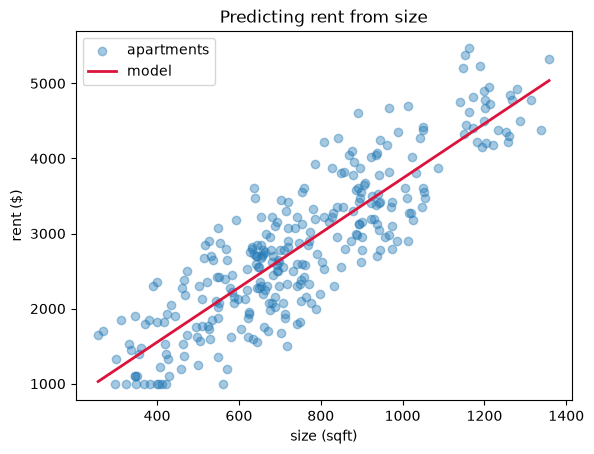

In [5]:
import numpy as np
import matplotlib.pyplot as plt

line = pd.DataFrame({"size_sqft": np.linspace(apts["size_sqft"].min(),
                                              apts["size_sqft"].max(), 100)})

plt.scatter(apts["size_sqft"], apts["rent"], alpha=0.4, label="apartments")
plt.plot(line["size_sqft"], model.predict(line), color="crimson", lw=2, label="model")
plt.xlabel("size (sqft)"); plt.ylabel("rent ($)")
plt.title("Predicting rent from size"); plt.legend()
plt.show()

## Which features should you use?

Size alone leaves a lot unexplained. Before adding more columns, check **which ones
actually relate to rent**. A quick tool: the **correlation** of each feature with the
target. Strong (near +1 or -1) is a good sign; near 0 means the feature carries little
signal.

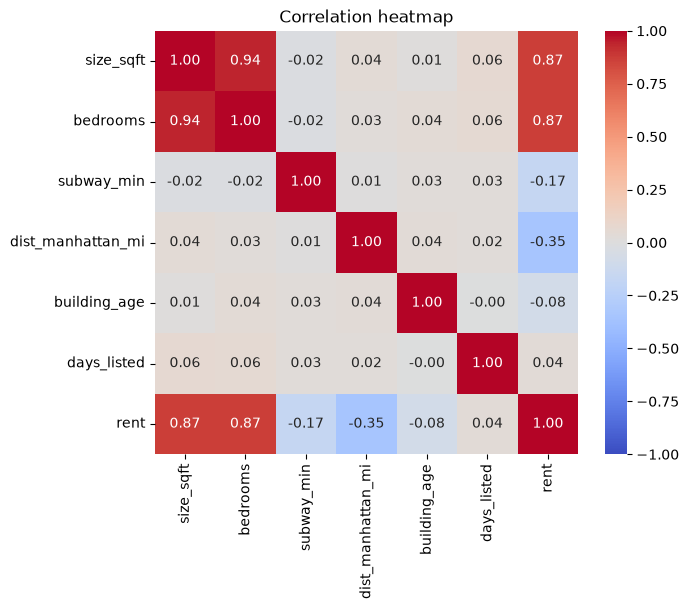

In [6]:
import seaborn as sns

corr = apts.corr(numeric_only=True)

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation heatmap")
plt.show()

Read the `rent` row (or column) on its own to rank the features:

In [7]:
apts.corr(numeric_only=True)["rent"].drop("rent").sort_values(ascending=False)

size_sqft            0.869804
bedrooms             0.868390
days_listed          0.038568
building_age        -0.083035
subway_min          -0.165237
dist_manhattan_mi   -0.347466
Name: rent, dtype: float64

That gives us three tiers:

- **Good features** (strong correlation): `size_sqft`, `bedrooms`, `dist_manhattan_mi`
- **OK features** (weak correlation): `subway_min`, `building_age`
- **Useless feature** (no correlation): `days_listed` sits near 0. How long a listing
  has been up tells us nothing about the rent.

The sign matters too: `subway_min` and `dist_manhattan_mi` are **negative**, so farther
away means cheaper.

## More features, same code

Add the good and OK features. Nothing else about the workflow changes: just widen `X`.

In [8]:
features = ["size_sqft", "bedrooms", "subway_min", "dist_manhattan_mi", "building_age"]

X_multi = apts[features]
big = LinearRegression().fit(X_multi, y)

for name, coef in zip(features, big.coef_):
    print(f"{name:20s} {coef:8.2f}")
print("\nR-squared", round(big.score(X_multi, y), 3))

size_sqft                2.08
bedrooms               467.64
subway_min             -25.82
dist_manhattan_mi     -116.75
building_age            -2.57

R-squared 0.951


R-squared jumped from the single-feature model: more (useful) features, a better fit.

### Does the useless feature help?

Add `days_listed` and refit. R-squared barely moves. A feature with no correlation
does not earn its place, so leave it out.

In [9]:
with_junk = features + ["days_listed"]
print("useful features only :", round(LinearRegression().fit(X_multi, y).score(X_multi, y), 4))
print("plus days_listed     :", round(LinearRegression().fit(apts[with_junk], y).score(apts[with_junk], y), 4))

useful features only : 0.9506
plus days_listed     : 0.9507


## Predict a specific apartment

Describe an apartment as a one-row DataFrame with the same columns, then predict.

In [10]:
new_apt = pd.DataFrame([{
    "size_sqft": 750,
    "bedrooms": 1,
    "subway_min": 4,
    "dist_manhattan_mi": 2.5,
    "building_age": 30,
}])

print("predicted rent: $", round(big.predict(new_apt)[0]))

predicted rent: $ 3366


## Proper practice: train and test on different rows

Scoring on the same data you trained on is optimistic. Real practice **splits** the
data: learn on one part, score on a part the model never saw.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=0)

checked = LinearRegression().fit(X_train, y_train)   # learn on the training rows
checked.score(X_test, y_test)                        # score on rows it never saw

0.9436946448562378

## The takeaway

**make -> fit -> predict** is the whole rhythm, and it is the *same* for every
scikit-learn model. Swap `LinearRegression()` for `KMeans()` or
`RandomForestClassifier()` and your code barely changes. Pick features that correlate
with the target, pick the model that matches your question, and the workflow stays put.